# Assignment 4: Binary Classification with 1D CNN

This notebook converts the appliance energy prediction problem into a binary classification task:

- `HighConsumption = 1` if `Appliances` is above the dataset median
- `HighConsumption = 0` otherwise

The workflow follows the assignment brief:

1. Load `energydata_complete.csv`
2. Create the binary target and check class balance
3. Build chronological history windows of 24 time steps
4. Train and compare 1D CNN configurations
5. Evaluate on the test set with confusion matrix and classification metrics
6. Compare the CNN against a logistic regression baseline
7. Save the best CNN model as `cnn_classifier.h5`


In [4]:
import os
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
pd.set_option("display.max_columns", None)


In [5]:
def locate_dataset() -> Path:
    candidates = [
        Path("data/energydata_complete.csv"),
        Path("Assignment4/data/energydata_complete.csv"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("energydata_complete.csv was not found in Assignment4/data")


data_path = locate_dataset()
project_dir = data_path.parent.parent
model_path = project_dir / "cnn_classifier.h5"

df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Dataset path: {data_path}")
print(f"Project directory: {project_dir}")
print(f"Shape: {df.shape}")
df.head()


Dataset path: /home/lux-ardenti/Desktop/AI&NN/SCANIA-Compenent-X-AI-NN-/Assignment4/data/energydata_complete.csv
Project directory: /home/lux-ardenti/Desktop/AI&NN/SCANIA-Compenent-X-AI-NN-/Assignment4
Shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


Median appliance consumption: 60.0
Class balance:
HighConsumption
Low / Normal    0.544413
High            0.455587
Name: proportion, dtype: float64


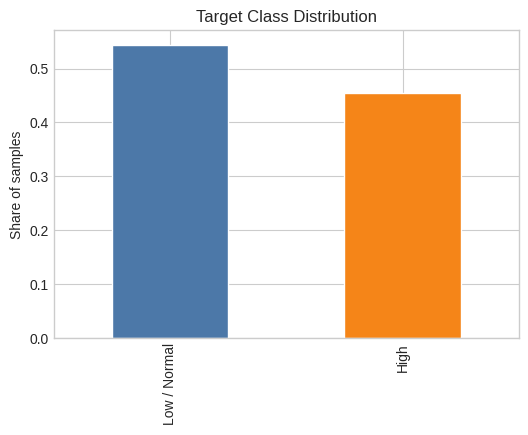

In [6]:
median_appliances = df["Appliances"].median()
df["HighConsumption"] = (df["Appliances"] > median_appliances).astype("int8")

class_balance = df["HighConsumption"].value_counts(normalize=True).sort_index()

print(f"Median appliance consumption: {median_appliances}")
print("Class balance:")
print(class_balance.rename(index={0: "Low / Normal", 1: "High"}))

fig, ax = plt.subplots(figsize=(6, 4))
class_balance.rename(index={0: "Low / Normal", 1: "High"}).plot(
    kind="bar", ax=ax, color=["#4C78A8", "#F58518"]
)
ax.set_title("Target Class Distribution")
ax.set_ylabel("Share of samples")
ax.set_xlabel("")
plt.show()


In [7]:
# Create compact cyclical time features from the timestamp.
df["hour"] = df["date"].dt.hour + df["date"].dt.minute / 60.0
df["day_of_week"] = df["date"].dt.dayofweek

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

feature_cols = [col for col in df.columns if col not in ["date", "HighConsumption", "hour", "day_of_week"]]

print(f"Number of input features: {len(feature_cols)}")
print(feature_cols)


Number of input features: 32
['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [8]:
WINDOW_SIZE = 24
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

n_rows = len(df)
train_end = int(n_rows * TRAIN_RATIO)
val_end = int(n_rows * (TRAIN_RATIO + VAL_RATIO))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Chronological split:")
for split_name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(
        f"{split_name}: {split_df.shape[0]:>5} rows | "
        f"{split_df['date'].min()} -> {split_df['date'].max()}"
    )


def make_sequences(features: np.ndarray, targets: np.ndarray, window_size: int):
    X_seq, y_seq = [], []
    for idx in range(window_size, len(features)):
        X_seq.append(features[idx - window_size : idx])
        y_seq.append(targets[idx])
    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.int32)


scaler = StandardScaler()
X_train_raw = train_df[feature_cols].astype("float32")
X_val_raw = val_df[feature_cols].astype("float32")
X_test_raw = test_df[feature_cols].astype("float32")

X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

y_train = train_df["HighConsumption"].to_numpy(dtype=np.int32)
y_val = val_df["HighConsumption"].to_numpy(dtype=np.int32)
y_test = test_df["HighConsumption"].to_numpy(dtype=np.int32)

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train, WINDOW_SIZE)
X_val_seq, y_val_seq = make_sequences(X_val_scaled, y_val, WINDOW_SIZE)
X_test_seq, y_test_seq = make_sequences(X_test_scaled, y_test, WINDOW_SIZE)

print("\nSequence tensors:")
print(f"X_train_seq: {X_train_seq.shape}, y_train_seq: {y_train_seq.shape}")
print(f"X_val_seq:   {X_val_seq.shape}, y_val_seq:   {y_val_seq.shape}")
print(f"X_test_seq:  {X_test_seq.shape}, y_test_seq:  {y_test_seq.shape}")


Chronological split:
Train: 13814 rows | 2016-01-11 17:00:00 -> 2016-04-16 15:10:00
Validation:  2960 rows | 2016-04-16 15:20:00 -> 2016-05-07 04:30:00
Test:  2961 rows | 2016-05-07 04:40:00 -> 2016-05-27 18:00:00

Sequence tensors:
X_train_seq: (13790, 24, 32), y_train_seq: (13790,)
X_val_seq:   (2936, 24, 32), y_val_seq:   (2936,)
X_test_seq:  (2937, 24, 32), y_test_seq:  (2937,)


In [9]:
minority_share = y_train_seq.mean()
majority_share = 1 - minority_share
imbalance_gap = abs(majority_share - minority_share)

class_weight = None
if imbalance_gap > 0.20:
    classes = np.unique(y_train_seq)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_seq)
    class_weight = {int(label): float(weight) for label, weight in zip(classes, weights)}

print(f"Train high-consumption share: {minority_share:.3f}")
print(f"Train low-consumption share:  {majority_share:.3f}")
print(f"Using class_weight: {class_weight}")


Train high-consumption share: 0.442
Train low-consumption share:  0.558
Using class_weight: None


In [10]:
def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


def build_cnn(window_size: int, n_features: int, filters: int, kernel_size: int):
    model = keras.Sequential(
        [
            layers.Input(shape=(window_size, n_features)),
            layers.Conv1D(filters=filters, kernel_size=kernel_size, activation="relu", padding="causal"),
            layers.MaxPooling1D(pool_size=2),
            layers.Flatten(),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.30),
            layers.Dense(1, activation="sigmoid"),
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model


cnn_configs = [
    {"filters": 64, "kernel_size": 3},
    {"filters": 128, "kernel_size": 5},
]

cnn_search_results = []
best_val_f1 = -1.0
best_config = None
best_checkpoint = None
best_history = None

for config in cnn_configs:
    tf.keras.backend.clear_session()
    checkpoint_path = project_dir / f"cnn_tmp_f{config['filters']}_k{config['kernel_size']}.keras"
    model = build_cnn(WINDOW_SIZE, X_train_seq.shape[-1], **config)

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True),
    ]

    history = model.fit(
        X_train_seq,
        y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=20,
        batch_size=64,
        verbose=0,
        class_weight=class_weight,
        callbacks=callbacks,
    )

    best_model = keras.models.load_model(checkpoint_path)
    val_probs = best_model.predict(X_val_seq, verbose=0).ravel()
    val_pred = (val_probs >= 0.5).astype(int)
    metrics = classification_metrics(y_val_seq, val_pred)

    cnn_search_results.append(
        {
            "filters": config["filters"],
            "kernel_size": config["kernel_size"],
            "epochs_ran": len(history.history["loss"]),
            **metrics,
        }
    )

    if metrics["F1"] > best_val_f1:
        best_val_f1 = metrics["F1"]
        best_config = config
        best_checkpoint = checkpoint_path
        best_history = history.history

cnn_results_df = pd.DataFrame(cnn_search_results).sort_values(["F1", "Accuracy"], ascending=False)
cnn_results_df


I0000 00:00:1776159702.057327    7713 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4798 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:04:00.0, compute capability: 8.6
I0000 00:00:1776159705.324399    8394 service.cc:153] XLA service 0x7aa414031470 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776159705.324419    8394 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776159705.389234    8394 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776159705.706461    8394 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776159705.772815    8394 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1732__.22
I0000 00:00:1776159707.071629    8394 dot_se

,filters,kernel_size,epochs_ran,Accuracy,Precision,Recall,F1
0,64,3,13,0.822888,0.853896,0.755747,0.801829
1,128,5,7,0.795981,0.801521,0.757184,0.778722


Best CNN configuration: {'filters': 64, 'kernel_size': 3}


Saved best CNN model to: /home/lux-ardenti/Desktop/AI&NN/SCANIA-Compenent-X-AI-NN-/Assignment4/cnn_classifier.h5


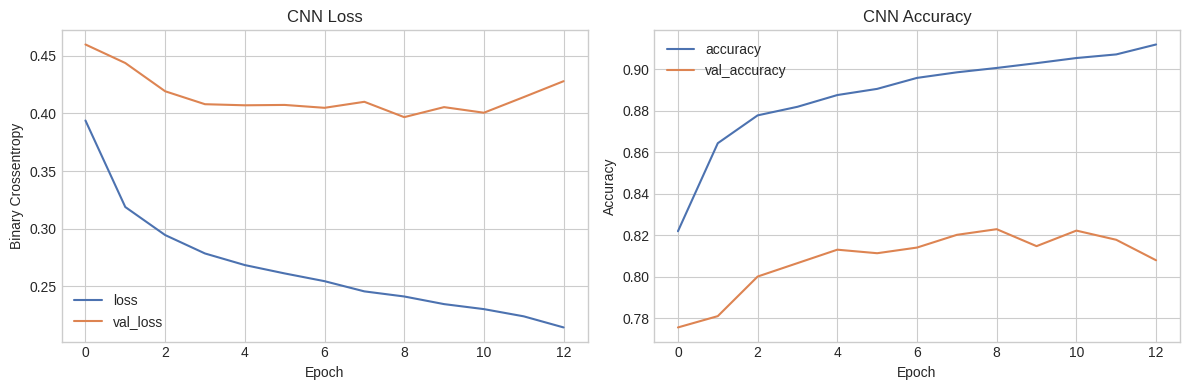

In [11]:
print(f"Best CNN configuration: {best_config}")
best_cnn_model = keras.models.load_model(best_checkpoint)
best_cnn_model.save(model_path)
print(f"Saved best CNN model to: {model_path}")

history_df = pd.DataFrame(best_history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[["loss", "val_loss"]].plot(ax=axes[0], title="CNN Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Crossentropy")

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="CNN Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()


CNN test metrics:
Accuracy: 0.7995
Precision: 0.7687
Recall: 0.8498
F1: 0.8072

Detailed classification report:
              precision    recall  f1-score   support

Low / Normal       0.84      0.75      0.79      1486
        High       0.77      0.85      0.81      1451

    accuracy                           0.80      2937
   macro avg       0.80      0.80      0.80      2937
weighted avg       0.80      0.80      0.80      2937



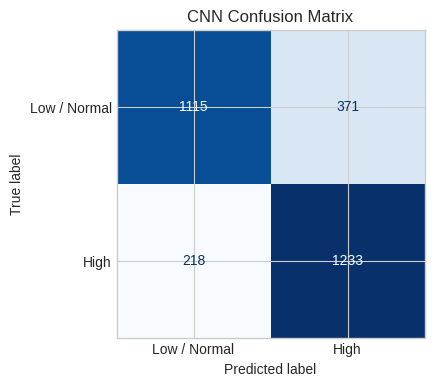

In [12]:
cnn_test_probs = best_cnn_model.predict(X_test_seq, verbose=0).ravel()
cnn_test_pred = (cnn_test_probs >= 0.5).astype(int)
cnn_metrics = classification_metrics(y_test_seq, cnn_test_pred)

print("CNN test metrics:")
for metric_name, metric_value in cnn_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

print("\nDetailed classification report:")
print(classification_report(y_test_seq, cnn_test_pred, target_names=["Low / Normal", "High"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_seq,
    cnn_test_pred,
    display_labels=["Low / Normal", "High"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("CNN Confusion Matrix")
plt.show()


In [13]:
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_val_flat = X_val_seq.reshape(X_val_seq.shape[0], -1)
X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)

baseline = LogisticRegression(
    max_iter=1500,
    class_weight="balanced" if class_weight is not None else None,
    random_state=SEED,
)
baseline.fit(X_train_flat, y_train_seq)

baseline_val_pred = baseline.predict(X_val_flat)
baseline_test_pred = baseline.predict(X_test_flat)

baseline_val_metrics = classification_metrics(y_val_seq, baseline_val_pred)
baseline_test_metrics = classification_metrics(y_test_seq, baseline_test_pred)

print("Baseline validation metrics:")
print(pd.Series(baseline_val_metrics))

print("\nBaseline test metrics:")
print(pd.Series(baseline_test_metrics))


Baseline validation metrics:
Accuracy     0.825954
Precision    0.838586
Recall       0.783764
F1           0.810249
dtype: float64

Baseline test metrics:
Accuracy     0.838270
Precision    0.822325
Recall       0.858029
F1           0.839798
dtype: float64


In [14]:
comparison_df = pd.DataFrame(
    [
        {"Model": "1D CNN", **cnn_metrics},
        {"Model": "Logistic Regression", **baseline_test_metrics},
    ]
).set_index("Model")

comparison_df.style.format("{:.4f}")


,Accuracy,Precision,Recall,F1
Model,,,,
1D CNN,0.7995,0.7687,0.8498,0.8072
Logistic Regression,0.8383,0.8223,0.8580,0.8398


## Conclusions

- The binary target is created from the median appliance consumption.
- The data split preserves chronology and uses rolling windows of 24 time steps.
- A 1D CNN is trained and compared against logistic regression on the same sequence representation.
- The best CNN model is saved to `cnn_classifier.h5` in the `Assignment4` directory.

If you rerun the notebook from top to bottom, it will regenerate the metrics, plots, confusion matrix, and saved model.
